### 1.Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import math

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

### 2. Load Dataset

In [4]:
train_data = pd.read_csv('Google_Stock_Train.csv')
test_data = pd.read_csv('Google_Stock_Test.csv')


### 3. Visualize Data

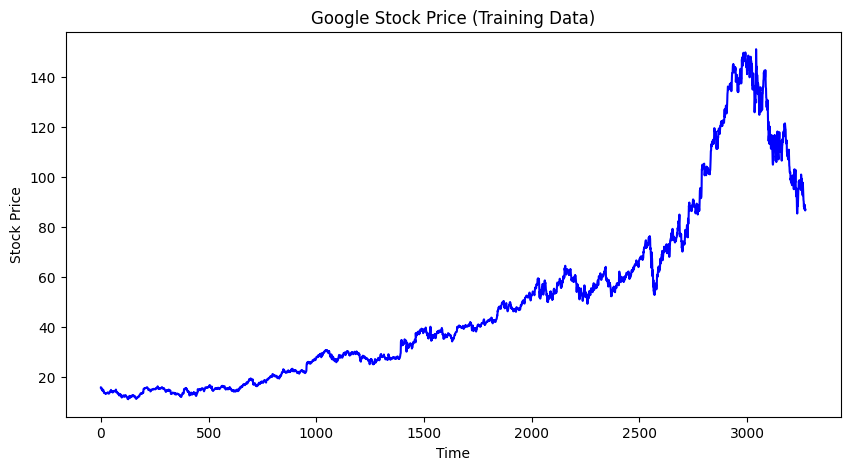

In [5]:
plt.figure(figsize=(10,5))
plt.plot(train_data['Open'], color='blue')
plt.title("Google Stock Price (Training Data)")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.show()

### 4. Normalize Data

In [6]:
scaler = MinMaxScaler(feature_range=(0,1))
training_set = train_data[['Open']].values


In [7]:
training_set_scaled = scaler.fit_transform(training_set)

### 5. Create Sequences (Windowing)

In [8]:
X_train = []
y_train = []

In [9]:
for i in range(60, len(training_set_scaled)):
    X_train.append(training_set_scaled[i-60:i, 0])
    y_train.append(training_set_scaled[i, 0])

In [10]:
X_train = np.array(X_train)
y_train = np.array(y_train)

In [11]:
# Reshape for LSTM [samples, time_steps, features]
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

### 6. Build LSTM Model

In [12]:
model = Sequential()

In [13]:
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1],1)))
model.add(Dropout(0.2))

D:\ANACONDA\envs\lpdeeplearn\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [14]:
model.add(LSTM(units=50, return_sequences=True))
model.add(Dropout(0.2))

In [15]:
model.add(LSTM(units=50))
model.add(Dropout(0.2))

In [16]:
model.add(Dense(units=1))

### 7. Train Model


In [17]:
model.compile(optimizer='adam', loss='mean_squared_error')


In [18]:
history = model.fit(X_train, y_train, epochs=20, batch_size=32)

Epoch 1/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 14s 75ms/step - loss: 0.0185
Epoch 2/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 8s 74ms/step - loss: 0.0019
Epoch 3/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - loss: 0.0019
Epoch 4/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - loss: 0.0015
Epoch 5/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 8s 77ms/step - loss: 0.0015
Epoch 6/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - loss: 0.0015
Epoch 7/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - loss: 0.0015
Epoch 8/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - loss: 0.0014
Epoch 9/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 11s 75ms/step - loss: 0.0012
Epoch 10/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 7s 70ms/step - loss: 0.0014
Epoch 11/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 8s 77ms/step - loss: 0.0012
Epoch 12/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - loss: 0.0011
Epoch 13/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 7s 68ms/step - loss: 0.0012
Epoch 14/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 7s 70ms/step - loss: 0.0010
Epoch 15/20
101/101 ━━━━━━━━━━━━━━━━━

### Training Loss Visualization

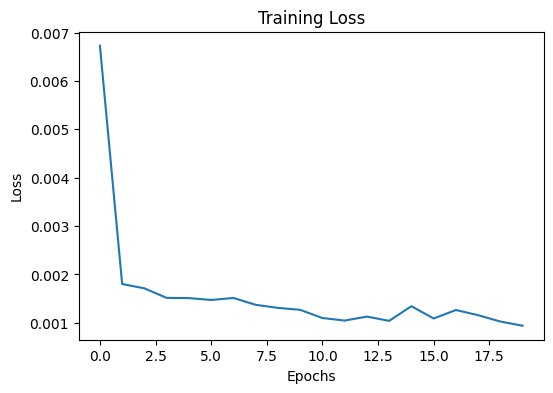

In [19]:
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'])
plt.title("Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

### 8. Prepare Test Data & Predict

In [20]:
real_stock_price = test_data[['Open']].values

dataset_total = pd.concat((train_data['Open'], test_data['Open']), axis=0)

inputs = dataset_total[len(dataset_total) - len(test_data) - 60:].values
inputs = inputs.reshape(-1,1)

inputs = scaler.transform(inputs)

X_test = []

for i in range(60, len(inputs)):
    X_test.append(inputs[i-60:i, 0])

X_test = np.array(X_test)

X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

#### Predict

In [21]:
predicted_stock_price = model.predict(X_test)
predicted_stock_price = scaler.inverse_transform(predicted_stock_price)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 160ms/step


### 9. Visualize Results

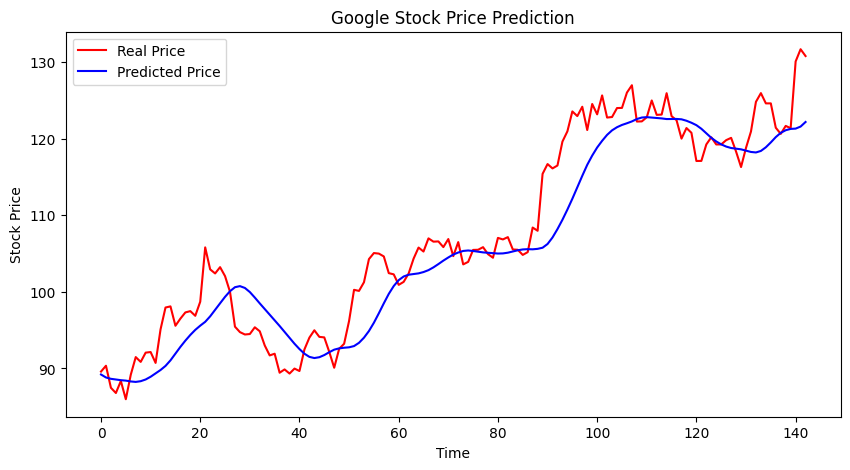

In [22]:
plt.figure(figsize=(10,5))
plt.plot(real_stock_price, color='red', label='Real Price')
plt.plot(predicted_stock_price, color='blue', label='Predicted Price')

plt.title("Google Stock Price Prediction")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()
plt.show()

### 10. Evaluate (RMSE)

In [23]:
rmse = math.sqrt(mean_squared_error(real_stock_price, predicted_stock_price))
print("RMSE:", rmse)

RMSE: 4.491793587631109
